# Montowanie Google Drive


## KROK 1 — Montowanie Google Drive

Montuje Google Drive i ustawia zmienną `path` wskazującą na folder ze zdjęciami.  
Jeśli zmieniasz lokalizację datasetu, zaktualizuj `FOLDER_ID` i `FOLDER_NAME`.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive zamontowany')

import os
FOLDER_ID = '1sSs_cneHbA8i2XZpq7SIZsHGwnWDloL3'
FOLDER_NAME = 'UMwTi'
PHOTO_FOLDER = 'zdjecia_RAW'
path = f'/content/drive/.shortcut-targets-by-id/{FOLDER_ID}/{FOLDER_NAME}/{PHOTO_FOLDER}'

print(os.listdir(path))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive zamontowany
['1K', 'ALL', 'ALL_NEW', 'sanity_check_db', 'sanity_check_out', '1K_out', '1K_out.zip']


# Instalacja zależności i pobieranie wag modelu

## KROK 2 — Instalacja zależności i pobieranie wag modeli

Instaluje wszystkie pakiety Pythona i klonuje Real-ESRGAN z GitHub (instalacja z PyPI nie udostępnia modułu `realesrgan`).  
Nakłada patch na `basicsr` dla kompatybilności z torchvision ≥ 0.17 (`functional_tensor` zostało usunięte).  
Pobiera wagi sieci do `/content/weights/` i sprawdza ich poprawność (rozmiar > 1 MB — strona błędu wget ma kilka KB).

In [2]:
import os, sys, glob, subprocess

# --- Instalacja pakietów ---
os.system('pip install -q basicsr facexlib gfpgan')
os.system('pip install -q lpips pytorch-msssim scikit-image')
os.system('pip install -q rawpy')

# --- Real-ESRGAN z repozytorium ---
if not os.path.exists('/content/Real-ESRGAN'):
    subprocess.run(['git', 'clone', 'https://github.com/xinntao/Real-ESRGAN.git',
                    '/content/Real-ESRGAN'], check=True)

os.chdir('/content/Real-ESRGAN')
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', 'requirements.txt'], check=True)
subprocess.run([sys.executable, 'setup.py', 'develop', '--quiet'], check=True)
os.chdir('/content')

if '/content/Real-ESRGAN' not in sys.path:
    sys.path.insert(0, '/content/Real-ESRGAN')

print('✅ Zależności zainstalowane')

# --- Patch basicsr: torchvision >= 0.17 usunęło functional_tensor ---
patched = 0
for filepath in glob.glob('/usr/local/lib/python3.12/dist-packages/basicsr/**/*.py', recursive=True):
    try:
        with open(filepath, 'r') as f:
            content = f.read()
        if 'from torchvision.transforms.functional_tensor import' in content:
            content = content.replace(
                'from torchvision.transforms.functional_tensor import',
                'from torchvision.transforms.functional import'
            )
            with open(filepath, 'w') as f:
                f.write(content)
            patched += 1
    except Exception:
        pass
print(f'✅ basicsr patch zastosowany ({patched} plik/pliki)')

# --- Wagi modeli ---
os.makedirs('/content/weights', exist_ok=True)

def is_valid_pth(path):
    return os.path.exists(path) and os.path.getsize(path) > 1024 * 1024

def download_weight(filename, url):
    path = f'/content/weights/{filename}'
    if not is_valid_pth(path):
        if os.path.exists(path):
            os.remove(path)
        ret = os.system(f'wget -q -O {path} {url}')
        print(f'{"✅" if ret==0 and is_valid_pth(path) else "❌"} {filename}')
    else:
        print(f'ℹ️  {filename} już istnieje')

download_weight('RealESRGAN_x4plus.pth',
    'https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth')
download_weight('RRDB_ESRGAN_x4.pth',
    'https://huggingface.co/ai-forever/Real-ESRGAN/resolve/main/RealESRGAN_x4.pth')

print('\n✅ Wszystkie wagi gotowe')


✅ Zależności zainstalowane
✅ basicsr patch zastosowany (0 plik/pliki)
ℹ️  RealESRGAN_x4plus.pth już istnieje
ℹ️  RRDB_ESRGAN_x4.pth już istnieje

✅ Wszystkie wagi gotowe


# Konfiguracja ścieżki

## KROK 3 — Konfiguracja pipeline'u

**Jedyne miejsce do ręcznej edycji.** Ustaw tutaj:
- `N` — limit zdjęć (`10` do sanity testu, `1000` do pełnego runu)
- `INPUT_DIR` / `OUTPUT_DIR` — ścieżki wejścia i wyjścia
- `SCALE_FACTORS` — współczynniki skalowania, domyślnie `[2, 4, 8]`
- `ENTROPY_MIN`, `NOISE_VAR_MAX` — progi filtrowania jakości patchy
- `SPLIT_RATIO` — proporcje train/val/test

Tworzy strukturę katalogów wyjściowych i zapisuje `pipeline_config.json`.

In [3]:
import os, json

INPUT_DIR  = os.path.join(path, '1K')
OUTPUT_DIR = '/content/1K_out'

# --- Skala i kadrowanie ---
SCALE_FACTORS    = [8, 16, 32]
RAW_CROP_SIZE    = 320   # patch losowany z PVS
TARGET_CROP_SIZE = 256   # środkowe wycięcie po pipeline
N_CANDIDATES     = 16    # ile kandydatów na obraz

# --- Filtry jakości patcha ---
ENTROPY_MIN   = 4.5      # minimalna entropia Shannona (bity)
NOISE_VAR_MAX = 2500     # max wariancja Laplaciana

# --- Splitowanie ---
SPLIT_RATIO = (0.70, 0.15, 0.15)   # train / val / test
SPLIT_SEED  = 42
STRESS_TEST_KEYWORDS = [
    'szachownica', 'checker', 'ai_gen', 'render',
    'anime', 'rysunek', 'drawing',
]

# --- Limit ←── zmień na 10 do sanity testu, 1000 do pełnego runu ---
N = 10

PIPELINE_VERSION = '0.5'
extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp', '.nef')

# --- Struktura katalogów wyjściowych ---
for subdir in ('train', 'val', 'test', 'stress_test'):
    os.makedirs(os.path.join(OUTPUT_DIR, subdir), exist_ok=True)

MANIFEST_PATH = os.path.join(OUTPUT_DIR, 'manifest.jsonl')
SPLITS_PATH   = os.path.join(OUTPUT_DIR, 'splits.json')

pipeline_config = {
    'scale_factors':        SCALE_FACTORS,
    'raw_crop_size':        RAW_CROP_SIZE,
    'target_crop_size':     TARGET_CROP_SIZE,
    'n_candidates':         N_CANDIDATES,
    'entropy_min':          ENTROPY_MIN,
    'noise_var_max':        NOISE_VAR_MAX,
    'split_ratio':          list(SPLIT_RATIO),
    'split_seed':           SPLIT_SEED,
    'stress_test_keywords': STRESS_TEST_KEYWORDS,
    'pipeline_version':     PIPELINE_VERSION,
    'n_limit':              N,
}
with open(os.path.join(OUTPUT_DIR, 'pipeline_config.json'), 'w') as f:
    json.dump(pipeline_config, f, indent=2)

if not os.path.exists(INPUT_DIR):
    print(f'⚠️  Folder wejściowy nie istnieje: {INPUT_DIR}')
else:
    images = [f for f in sorted(os.listdir(INPUT_DIR)) if f.lower().endswith(extensions)]
    print(f'✅ Folder wejściowy  : {INPUT_DIR}')
    print(f'✅ Folder wyjściowy  : {OUTPUT_DIR}')
    print(f'📷 Znalezione zdjęcia: {len(images)}')
    print(f'🔢 Limit N           : {N}')
    print(f'📐 Scale factors     : {SCALE_FACTORS}')
    print(f'✅ pipeline_config.json zapisany')


✅ Folder wejściowy  : /content/drive/.shortcut-targets-by-id/1sSs_cneHbA8i2XZpq7SIZsHGwnWDloL3/UMwTi/zdjecia_RAW/1K
✅ Folder wyjściowy  : /content/1K_out
📷 Znalezione zdjęcia: 1000
🔢 Limit N           : 10
📐 Scale factors     : [8, 16, 32]
✅ pipeline_config.json zapisany


# Inne importy

## KROK 4 — Importy i sprawdzenie GPU

Importuje biblioteki PyTorch, PIL, NumPy, OpenCV. Wykrywa dostępność GPU i ustawia zmienną `DEVICE` (`cuda` lub `cpu`).

In [4]:
import sys
import json
import time
import numpy as np
from PIL import Image, ImageFilter
import cv2
import torch
from pathlib import Path

print(f'PyTorch: {torch.__version__}')
print(f'CUDA dostępna: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Urządzenie: {DEVICE}')

PyTorch: 2.10.0+cpu
CUDA dostępna: False
Urządzenie: cpu


# Inicjalizacja modeli

## KROK 5 — Inicjalizacja modeli SR

Ładuje dwa modele ESRGAN ×4 do pamięci GPU (wykonywane tylko raz na sesję):
- **Real-ESRGAN** (`RealESRGAN_x4plus.pth`) — model z generatorem perceptualnym, wytrenowany na syntetycznych degradacjach
- **ESRGAN classic** (`RRDB_ESRGAN_x4.pth`) — oryginalny ESRGAN z 2018 r., bliższy teksturom rzeczywistym


In [5]:
import sys, os
import torch

if '/content/Real-ESRGAN' not in sys.path:
    sys.path.insert(0, '/content/Real-ESRGAN')

# Napraw format checkpointów bez klucza 'params' (klasyczne ESRGAN)
def fix_checkpoint(path):
    ckpt = torch.load(path, map_location='cpu')
    if not isinstance(ckpt, dict) or ('params' not in ckpt and 'params_ema' not in ckpt):
        torch.save({'params': ckpt}, path)
        print(f'  ⚙️  Naprawiono format: {os.path.basename(path)}')

fix_checkpoint('/content/weights/RRDB_ESRGAN_x4.pth')

from realesrgan import RealESRGANer
from basicsr.archs.rrdbnet_arch import RRDBNet

# Modele zawsze działają w trybie x4; skalowanie do docelowego SF odbywa się w _esrgan_enhance
_MODEL_SCALE = 4

# --- Real-ESRGAN ---
realesrgan_model = RRDBNet(
    num_in_ch=3, num_out_ch=3, num_feat=64,
    num_block=23, num_grow_ch=32, scale=_MODEL_SCALE
)
realesrgan_upsampler = RealESRGANer(
    scale=_MODEL_SCALE,
    model_path='/content/weights/RealESRGAN_x4plus.pth',
    model=realesrgan_model,
    tile=0, tile_pad=10, pre_pad=0,
    half=(DEVICE == 'cuda')
)
print('✅ Real-ESRGAN załadowany')

# --- ESRGAN classic ---
esrgan_classic_model = RRDBNet(
    num_in_ch=3, num_out_ch=3, num_feat=64,
    num_block=23, num_grow_ch=32, scale=_MODEL_SCALE
)
esrgan_classic_upsampler = RealESRGANer(
    scale=_MODEL_SCALE,
    model_path='/content/weights/RRDB_ESRGAN_x4.pth',
    model=esrgan_classic_model,
    tile=0, tile_pad=10, pre_pad=0,
    half=(DEVICE == 'cuda')
)
print('✅ ESRGAN classic załadowany')


✅ Real-ESRGAN załadowany
✅ ESRGAN classic załadowany


## KROK 5b — Deterministyczny podział na zbiory

Przypisuje każdy plik źródłowy do jednego zbioru **przed** przetwarzaniem — eliminuje przecieki (ten sam obraz nie trafi jednocześnie do train i test).

- Pliki zawierające słowa z `STRESS_TEST_KEYWORDS` w nazwie → `stress_test` (zdjęcia syntetyczne, rendery)
- Pozostałe → przetasowane z `SPLIT_SEED=42`, podzielone wg `SPLIT_RATIO` (domyślnie 70/15/15)

Wynik zapisywany do `splits.json`.

In [6]:
import hashlib, random, json

def _sha1(s: str) -> str:
    return hashlib.sha1(s.encode()).hexdigest()

# Zlistuj pliki (do limitu N)
all_files = sorted([
    f for f in os.listdir(INPUT_DIR)
    if f.lower().endswith(extensions)
])[:N]

# Przypisz stress_test po słowach kluczowych, resztę losuj
stress_kw = [k.lower() for k in STRESS_TEST_KEYWORDS]
regular, stress = [], []
for f in all_files:
    if any(kw in f.lower() for kw in stress_kw):
        stress.append(f)
    else:
        regular.append(f)

rng_split = random.Random(SPLIT_SEED)
shuffled  = regular.copy()
rng_split.shuffle(shuffled)

n       = len(shuffled)
n_train = int(n * SPLIT_RATIO[0])
n_val   = int(n * SPLIT_RATIO[1])

assignments = {}
for f in shuffled[:n_train]:              assignments[f] = 'train'
for f in shuffled[n_train:n_train+n_val]: assignments[f] = 'val'
for f in shuffled[n_train+n_val:]:        assignments[f] = 'test'
for f in stress:                           assignments[f] = 'stress_test'

counts = {s: sum(1 for v in assignments.values() if v == s)
          for s in ('train', 'val', 'test', 'stress_test')}

splits_data = {
    'seed': SPLIT_SEED, 'ratio': list(SPLIT_RATIO),
    'assignments': assignments, 'counts': counts,
}
with open(SPLITS_PATH, 'w') as f:
    json.dump(splits_data, f, indent=2)

def get_split(filename: str) -> str:
    return assignments.get(filename, 'test')

print(f'✅ Splits zapisane → {SPLITS_PATH}')
for s, c in counts.items():
    print(f'   {s:15s}: {c}')


✅ Splits zapisane → /content/1K_out/splits.json
   train          : 7
   val            : 1
   test           : 2
   stress_test    : 0


## KROK 6 — Funkcje przetwarzania i pary algorytmów

Definiuje wszystkie funkcje pomocnicze używane przez główną pętlę:

- **`smart_crop`** — losuje `N_CANDIDATES` patchy 320×320, wybiera ten z najwyższą entropią Shannona spełniający próg szumu; fallback do centrum jeśli żaden nie przejdzie filtru
- **`center_crop`** — wycina środek 256×256 z patcha 320×320 po skalowaniu
- **`downscale_*` / `upscale_*`** — funkcje skalowania, wszystkie o sygnaturze `(img, sf)`
- **`_esrgan_enhance`** — zawsze uruchamia model w trybie ×4; jeśli `sf ≠ 4`, stosuje dodatkowy resize przez LANCZOS do docelowego rozmiaru

**4 pary algorytmów** (`ALGORITHM_PAIRS`):

| Para | Downscale | Upscale | Kategoria artefaktów |
|:----:|-----------|---------|----------------------|
| 1 | Nearest Neighbor | Nearest Neighbor | aliasing, artefakty geometryczne |
| 2 | Box Filter | Bicubic | rozmycie, utrata wysokich częstotliwości |
| 3 | Bicubic | Real-ESRGAN | halucynacje AI |
| 4 | Lanczos | ESRGAN classic | wierność vs. wygląd |

In [7]:
# ---- Downscaling (wszystkie: img, sf) ----

def downscale_identity(img, sf): return img  # Klasa kontrolna
def downscale_nearest(img, sf): w, h = img.size; return img.resize((w//sf, h//sf), Image.NEAREST)
def downscale_box(img, sf):     w, h = img.size; return img.resize((w//sf, h//sf), Image.BOX)
def downscale_bicubic(img, sf): w, h = img.size; return img.resize((w//sf, h//sf), Image.BICUBIC)
def downscale_lanczos(img, sf): w, h = img.size; return img.resize((w//sf, h//sf), Image.LANCZOS)

# ---- Upscaling (wszystkie: img, sf) ----

def upscale_identity(img, sf): return img  # Klasa kontrolna

def upscale_nearest(img, sf):
    w, h = img.size; return img.resize((w*sf, h*sf), Image.NEAREST)

def upscale_bicubic(img, sf):
    w, h = img.size; return img.resize((w*sf, h*sf), Image.BICUBIC)

def _esrgan_enhance(upsampler, img, sf):
    """Model zawsze robi x4; jeśli sf != 4, resize do sf*oryginał."""
    img_bgr  = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    out_bgr, _ = upsampler.enhance(img_bgr, outscale=4)
    out      = Image.fromarray(cv2.cvtColor(out_bgr, cv2.COLOR_BGR2RGB))
    tw, th   = img.size[0] * sf, img.size[1] * sf
    if out.size != (tw, th):
        out = out.resize((tw, th), Image.LANCZOS)
    return out

def upscale_realesrgan(img, sf):
    return _esrgan_enhance(realesrgan_upsampler, img, sf)

def upscale_esrgan_classic(img, sf):
    return _esrgan_enhance(esrgan_classic_upsampler, img, sf)

def esrgan_upscale_method(sf):
    return 'native_x4' if sf == 4 else 'native_x4_then_resize'

# ---- Pary algorytmów ----

PAIR_GROUPS = {
    0: 'oryginal_brak_kompresji',       # Dodana grupa kontrolna
    1: 'artefakty_geometryczne_aliasing',
    2: 'rozmycie_utrata_informacji',
    3: 'halucynacje_AI',
    4: 'wiernosc_vs_wyglad',
}

ALGORITHM_PAIRS = [
    # Klasa kontrolna (brak degradacji, etykieta sf=1)
    {'pair_id': 0, 'down_name': 'Original (Control)', 'down_abbr': 'CTRL',
     'up_name': 'Original (Control)', 'up_abbr': 'CTRL',
     'downscale': downscale_identity, 'upscale': upscale_identity,
     'upscale_method': 'identity'},
     {'pair_id': 1, 'down_name': 'Nearest Neighbor', 'down_abbr': 'NN',
     'up_name': 'Bicubic', 'up_abbr': 'BIC',
     'downscale': downscale_nearest, 'upscale': upscale_bicubic,
     'upscale_method': 'native'},

    {'pair_id': 2, 'down_name': 'Box Filter', 'down_abbr': 'BOX',
     'up_name': 'Bicubic', 'up_abbr': 'BIC',
     'downscale': downscale_box, 'upscale': upscale_bicubic,
     'upscale_method': 'native'},

    {'pair_id': 3, 'down_name': 'Bicubic', 'down_abbr': 'BIC',
     'up_name': 'Real-ESRGAN', 'up_abbr': 'RESRGAN',
     'downscale': downscale_bicubic, 'upscale': upscale_realesrgan,
     'upscale_method': esrgan_upscale_method}, # Zamiast None, przekazujemy funkcję

    {'pair_id': 4, 'down_name': 'Lanczos', 'down_abbr': 'LANCZOS',
     'up_name': 'ESRGAN (classic)', 'up_abbr': 'ESRGAN',
     'downscale': downscale_lanczos, 'upscale': upscale_esrgan_classic,
     'upscale_method': esrgan_upscale_method}, # Zamiast None, przekazujemy funkcję
]

print('✅ Smart crop i algorytmy gotowe')
for p in ALGORITHM_PAIRS:
    print(f"  Para {p['pair_id']}: {p['down_name']} → {p['up_name']}")

✅ Smart crop i algorytmy gotowe
  Para 0: Original (Control) → Original (Control)
  Para 1: Nearest Neighbor → Bicubic
  Para 2: Box Filter → Bicubic
  Para 3: Bicubic → Real-ESRGAN
  Para 4: Lanczos → ESRGAN (classic)


## KROK 6b — Metryki jakości, cechy spektralne FFT i cechy NR

Inicjalizuje model LPIPS (AlexNet, ładowany raz na GPU) i definiuje funkcje metryk.

**Metryki full-reference** (każdy przetworzony patch vs. oryginał):
- `PSNR` — szczytowy SNR [dB]; dla oryginału = ∞
- `SSIM` — strukturalne podobieństwo [0, 1]
- `MS-SSIM` — wieloskalowy SSIM [0, 1]
- `LPIPS` — perceptualna odległość (AlexNet) [0, ~1]; niżej = lepiej
- `pseudo_mos` — łączona ocena: `0.3·PSNR_norm + 0.3·SSIM + 0.4·(1 − LPIPS/0.7)`, zakres [0, 1]

**Cechy FFT** (widmo mocy 2D → cechy skalarne):
- `hf_energy_ratio` — udział energii wysokich częstotliwości (r > W/4)
- `mf_energy_ratio` — udział energii średnich częstotliwości (W/8 ≤ r ≤ W/4)
- `spectrum_entropy` — entropia widma
- `radial_profile_decile` — profil radialny w 10 pierścieniach (znormalizowany)

**Cechy no-reference** — `patch_stats(img)` na obrazie RGB/gray → 3 cechy skalarne:
- `entropy_bits` — entropia Shannona histogramu 256-binowego [0, 8]; wyższa = więcej informacji
- `noise_var_laplacian` — wariancja filtru Laplace'a; proxy ostrości/szumu
- `mean_gradient` — średnia magnituda gradientu Sobela; proxy gęstości krawędzi

Używanie `patch_stats`:
- na `orig_256` → `crop.mean_gradient` (diagnostyka) + `patch_stats_result` dla oryginału
- na `result_256` → `patch_stats_result` (wchodzi do modelu jako NR input)
- na `low_res` → `patch_stats_low_res` (diagnostyka, porównanie przed/po upscalingu)

## KROK 7 — Główna pętla pipeline'u

Przetwarza N zdjęć RAW. Dla każdego pliku:
1. Otwiera plik NEF przez `rawpy` i konwertuje do RGB
2. Wybiera patch 320×320 przez `smart_crop`
3. Zapisuje oryginał 256×256 (center crop) jako PNG + wpis `type=oryginal` w manifeście
4. Dla każdego `sf` ∈ `SCALE_FACTORS` × 4 pary algorytmów:
   - downscale patch → low-res
   - upscale low-res → high-res 320×320
   - center crop do 256×256
   - oblicza PSNR, SSIM, MS-SSIM, LPIPS, pseudo_mos, cechy FFT
   - zapisuje PNG + wpis `type=processed` w manifeście

Łącznie `N × (1 + |SCALE_FACTORS| × |ALGORITHM_PAIRS|)` wpisów w manifeście.

> **Uwaga:** manifest otwierany w trybie `append`. Przed ponownym uruchomieniem usuń stary plik `manifest.jsonl`.

In [8]:
import numpy as np
import torch
import cv2
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from pytorch_msssim import ms_ssim as _ms_ssim
import lpips as _lpips_lib

# --- LPIPS model (ładowany raz) ---
_lpips_model = _lpips_lib.LPIPS(net='alex').to(DEVICE)
_lpips_model.eval()
print('✅ LPIPS (alex) załadowany')

# --- Cechy no-reference (NR): model widzi tylko zdegradowany obraz ---
import numpy as np
import cv2
from PIL import Image

# --- 1. SZYBKIE FUNKCJE METRYK (na patchach w skali szarości) ---

def shannon_entropy_8bit(gray_arr: np.ndarray) -> float:
    """Oblicza entropię Shannona - mówi nam, jak dużo informacji/szczegółów jest w kadrze."""
    # Szybki histogram z użyciem numpy
    hist, _ = np.histogram(gray_arr, bins=256, range=(0, 256))
    p = hist / (hist.sum() + 1e-12)
    p = p[p > 0]
    return float(-np.sum(p * np.log2(p)))

def laplacian_variance(gray_arr: np.ndarray) -> float:
    """Wariancja Laplasjanu - wykrywa ostrość i ilość szumu."""
    lap = cv2.Laplacian(gray_arr, cv2.CV_64F)
    return float(lap.var())

def mean_gradient_sobel(gray_arr: np.ndarray) -> float:
    """Średni gradient Sobela - mówi nam, jak wyraźne są krawędzie."""
    sx = cv2.Sobel(gray_arr, cv2.CV_64F, 1, 0, ksize=3)
    sy = cv2.Sobel(gray_arr, cv2.CV_64F, 0, 1, ksize=3)
    return float(np.sqrt(sx**2 + sy**2).mean())

# --- 2. GŁÓWNA FUNKCJA SMART CROP ---

def smart_crop(img_pil: Image.Image, raw_size: int, target_size: int, 
               n_candidates: int, ent_min: float, noise_var_max: float, rng) -> dict:
    """
    Losuje n_candidates obszarów, ocenia je pod kątem bogactwa detali i zwraca najlepszy.
    """
    w, h = img_pil.size
    
    # Zabezpieczenie: jeśli obraz bazowy jest mniejszy niż docelowy patch
    if w < raw_size or h < raw_size:
        img_pil = img_pil.resize((max(w, raw_size), max(h, raw_size)), Image.LANCZOS)
        w, h = img_pil.size

    candidates = []

    # 1. Losowanie i ewaluacja kandydatów
    for _ in range(n_candidates):
        x = rng.randint(0, w - raw_size)
        y = rng.randint(0, h - raw_size)
        
        # Wycinamy kandydata
        patch_pil = img_pil.crop((x, y, x + raw_size, y + raw_size))
        
        # Konwersja na grayscale do szybkiego policzenia metryk
        patch_arr = np.array(patch_pil)
        if patch_arr.ndim == 3:
            gray = cv2.cvtColor(patch_arr, cv2.COLOR_RGB2GRAY)
        else:
            gray = patch_arr
            
        # Obliczanie metryk
        ent = shannon_entropy_8bit(gray)
        var = laplacian_variance(gray)
        grad = mean_gradient_sobel(gray)
        
        candidates.append({
            'patch_pil': patch_pil,
            'coords': (x, y),
            'entropy': ent,
            'noise_var': var,
            'mean_gradient': grad
        })

    # 2. Filtrowanie (odrzucamy płaskie niebo i skrajny szum)
    valid_candidates = [
        c for c in candidates 
        if c['entropy'] >= ent_min and c['noise_var'] <= noise_var_max
    ]
    
    # 3. Wybór najlepszego (sortujemy głównie po entropii)
    fallback_used = False
    if valid_candidates:
        best_candidate = max(valid_candidates, key=lambda c: c['entropy'])
    else:
        # FALLBACK: Jeśli żaden nie spełnia warunków, bierzemy po prostu ten
        # z największą entropią z całej wylosowanej puli, by nie zepsuć pipeline'u.
        fallback_used = True
        best_candidate = max(candidates, key=lambda c: c['entropy'])

    best_patch = best_candidate['patch_pil']
    
    # 4. Opcjonalny resize (jeśli raw_size jest inny niż docelowy target_size)
    if raw_size != target_size:
        best_patch = best_patch.resize((target_size, target_size), Image.LANCZOS)

    return {
        'patch_pil': best_patch,
        'top_left_xy': best_candidate['coords'],
        'entropy': best_candidate['entropy'],
        'noise_var': best_candidate['noise_var'],
        'mean_gradient': best_candidate['mean_gradient'],
        'fallback_used': fallback_used,
        'candidates_evaluated': n_candidates
    }

def patch_stats(img_rgb_uint8) -> dict:
    """3 NR cechy na obrazie szarościowym: entropia, wariancja Laplaciana, średni gradient."""
    if img_rgb_uint8.ndim == 3:
        gray = cv2.cvtColor(img_rgb_uint8, cv2.COLOR_RGB2GRAY)
    else:
        gray = img_rgb_uint8

    hist, _ = np.histogram(gray, bins=256, range=(0, 256))
    p = hist / (hist.sum() + 1e-12)
    p = p[p > 0]
    entropy = float(-np.sum(p * np.log2(p)))

    lap = cv2.Laplacian(gray, cv2.CV_64F)
    noise_var = float(lap.var())

    sx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    mean_grad = float(np.sqrt(sx**2 + sy**2).mean())

    return {
        'entropy_bits':        round(entropy,   4),
        'noise_var_laplacian': round(noise_var, 4),
        'mean_gradient':       round(mean_grad, 4),
    }

print('✅ Metryki jakości i FFT gotowe (PSNR, SSIM, MS-SSIM, LPIPS, FFT)')
print('✅ patch_stats() gotowe')


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
✅ LPIPS (alex) załadowany
✅ Metryki jakości i FFT gotowe (PSNR, SSIM, MS-SSIM, LPIPS, FFT)
✅ patch_stats() gotowe


In [9]:
import os
import json
import hashlib
import random
from datetime import datetime, timezone
from time import time
from PIL import Image
import numpy as np
import gc
import torch

# --- 1. FUNKCJE POMOCNICZE ---

def get_split(filename, ratio, seed, keywords):
    name_lower = filename.lower()
    if any(kw in name_lower for kw in keywords):
        return 'stress_test'

    rng = random.Random(f"{filename}_{seed}")
    r = rng.random()
    train_r, val_r, _ = ratio
    if r < train_r: return 'train'
    elif r < train_r + val_r: return 'val'
    else: return 'test'

def load_base_image(path):
    """Bezpieczne ładowanie zarówno RAWów jak i zwykłych formatów."""
    if path.lower().endswith(('.raw', '.dng', '.cr2', '.nef', '.arw')):
        import rawpy
        with rawpy.imread(path) as raw:
            rgb = raw.postprocess()
        return Image.fromarray(rgb)
    else:
        return Image.open(path).convert('RGB')

def center_crop(pil_img, target_size):
    w, h = pil_img.size
    left = (w - target_size) // 2
    top = (h - target_size) // 2
    return pil_img.crop((left, top, left + target_size, top + target_size))

# --- 2. GŁÓWNA PĘTLA PIPELINE'U ---

print('=' * 60)
print(f'🚀 Start generacji zbioru danych (Limit: {N} zdjęć)')
print(f'📄 Manifest: {MANIFEST_PATH}')
print('=' * 60)

# Otwieramy manifest w trybie append z buforowaniem linii
manifest_file = open(MANIFEST_PATH, 'a', encoding='utf-8', buffering=1)

pipeline_start = time()
written = 0
image_files = sorted([f for f in os.listdir(INPUT_DIR) if f.lower().endswith(extensions)])[:N]
total_images = len(image_files)

for img_idx, filename in enumerate(image_files, start=1):
    img_path = os.path.join(INPUT_DIR, filename)
    source_hash = hashlib.sha1(filename.encode()).hexdigest()
    source_id = source_hash[:12]
    
    # Przypisanie do zbioru
    split = get_split(filename, SPLIT_RATIO, SPLIT_SEED, STRESS_TEST_KEYWORDS)
    out_subdir = os.path.join(OUTPUT_DIR, split)
    
    # Unikalny generator liczb losowych dla tego pliku (powtarzalność)
    rng = random.Random(int(source_id, 16) & 0xFFFFFFFF)

    elapsed_so_far = time() - pipeline_start
    print(f'[{img_idx}/{total_images}] 📷 {filename} | Split: {split} | Czas: {elapsed_so_far:.0f}s')

    try:
        # Wczytanie obrazu i krytyczne zabezpieczenie VRAM (Max 2K)
        raw_pil = load_base_image(img_path)
        raw_pil.thumbnail((2048, 2048), Image.LANCZOS)
        raw_full_size = list(raw_pil.size)

        for sf in SCALE_FACTORS:
            for pair in ALGORITHM_PAIRS:
                pair_id = pair['pair_id']
                t0 = time()

                # KROK A: Przetwarzanie CAŁEGO obrazu
                low_res_full = pair['downscale'](raw_pil, sf)
                high_res_full = pair['upscale'](low_res_full, sf)

                # KROK B: Smart Crop na zdegradowanym obrazie (rozmiar RAW_CROP_SIZE = 320)
                crop_info = smart_crop(
                    high_res_full, 
                    raw_size=RAW_CROP_SIZE, target_size=RAW_CROP_SIZE,
                    n_candidates=N_CANDIDATES, ent_min=ENTROPY_MIN, 
                    noise_var_max=NOISE_VAR_MAX, rng=rng
                )
                patch_320 = crop_info['patch_pil']
                x, y = crop_info['top_left_xy']

                # KROK C: Center Crop (z 320 na 256)
                result_256 = center_crop(patch_320, TARGET_CROP_SIZE)

                # KROK D: Zapis na dysk
                sample_id = f'{source_id}_p{pair_id}_s{sf}'
                out_filename = f'{sample_id}.png'
                out_path = os.path.join(out_subdir, out_filename)
                result_256.save(out_path, 'PNG')

                elapsed = time() - t0

                # Metadane algorytmu upscalingu
                up_method = pair['upscale_method'](sf) if callable(pair['upscale_method']) else pair['upscale_method']

                # Budowa rekordu JSONL
                entry = {
                    'sample_id': sample_id,
                    'source_image_id': source_id,
                    'source_file': filename,
                    'source_full_size_px': raw_full_size,
                    'split': split,
                    'is_stress_test': split == 'stress_test',
                    'pair_id': pair_id,
                    'degradation': {
                        'downscale': {'name': pair['down_name'], 'abbr': pair['down_abbr']},
                        'upscale':   {'name': pair['up_name'],   'abbr': pair['up_abbr'], 'method': up_method},
                        'scale_factor': sf
                    },
                    'crop': {
                        'raw_size_px': RAW_CROP_SIZE,
                        'target_size_px': TARGET_CROP_SIZE,
                        'top_left_xy': [x, y],
                        'entropy_bits': round(crop_info['entropy'], 4),
                        'noise_var_laplacian': round(crop_info['noise_var'], 2),
                        'fallback_used': crop_info['fallback_used']
                    },
                    'file': {
                        'path_relative': f'{split}/{out_filename}',
                        'format': 'PNG',
                        'size_bytes': os.path.getsize(out_path)
                    },
                    'processing': {
                        'time_s': round(elapsed, 3),
                        'pipeline_version': PIPELINE_VERSION,
                        'timestamp': datetime.now(timezone.utc).strftime('%Y-%m-%dT%H:%M:%SZ')
                    }
                }
                
                manifest_file.write(json.dumps(entry, ensure_ascii=False) + '\n')
                written += 1

    except Exception as exc:
        print(f'  ❌ Błąd przetwarzania {filename}: {exc}')
        import traceback; traceback.print_exc()
        
    finally:
        # AGRESYWNE CZYSZCZENIE PAMIĘCI
        for var in ('raw_pil', 'low_res_full', 'high_res_full', 'patch_320', 'result_256'):
            if var in locals():
                del locals()[var]
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

manifest_file.flush()
manifest_file.close()

total_time = time() - pipeline_start
print('\n' + '=' * 60)
print(f'🏁 Pipeline zakończony sukcesem!')
print(f'   Wykorzystanych obrazów: {min(total_images, N)}')
print(f'   Zapisanych wycinków   : {written}')
print(f'   Czas całkowity        : {total_time:.1f}s ({total_time/60:.1f} min)')
print(f'   Plik manifestu        : {MANIFEST_PATH}')
print('=' * 60)

🚀 Start generacji zbioru danych (Limit: 10 zdjęć)
📄 Manifest: /content/1K_out/manifest.jsonl
[1/10] 📷 r000da54ft.NEF | Split: train | Czas: 0s
[2/10] 📷 r001d260dt.NEF | Split: val | Czas: 81s
[5/10] 📷 r005f3e70t.NEF | Split: train | Czas: 319s
[6/10] 📷 r00617aa1t.NEF | Split: train | Czas: 399s
[7/10] 📷 r00679daet.NEF | Split: val | Czas: 478s
[8/10] 📷 r006b0e4bt.NEF | Split: train | Czas: 558s
[9/10] 📷 r006fcc20t.NEF | Split: train | Czas: 640s
[10/10] 📷 r007f5116t.NEF | Split: test | Czas: 719s

🏁 Pipeline zakończony sukcesem!
   Wykorzystanych obrazów: 10
   Zapisanych wycinków   : 150
   Czas całkowity        : 798.5s (13.3 min)
   Plik manifestu        : /content/1K_out/manifest.jsonl


📷 Sanity Check na obrazie: r000da54ft.NEF
📍 Zamrożone współrzędne do porównania: x=930, y=324


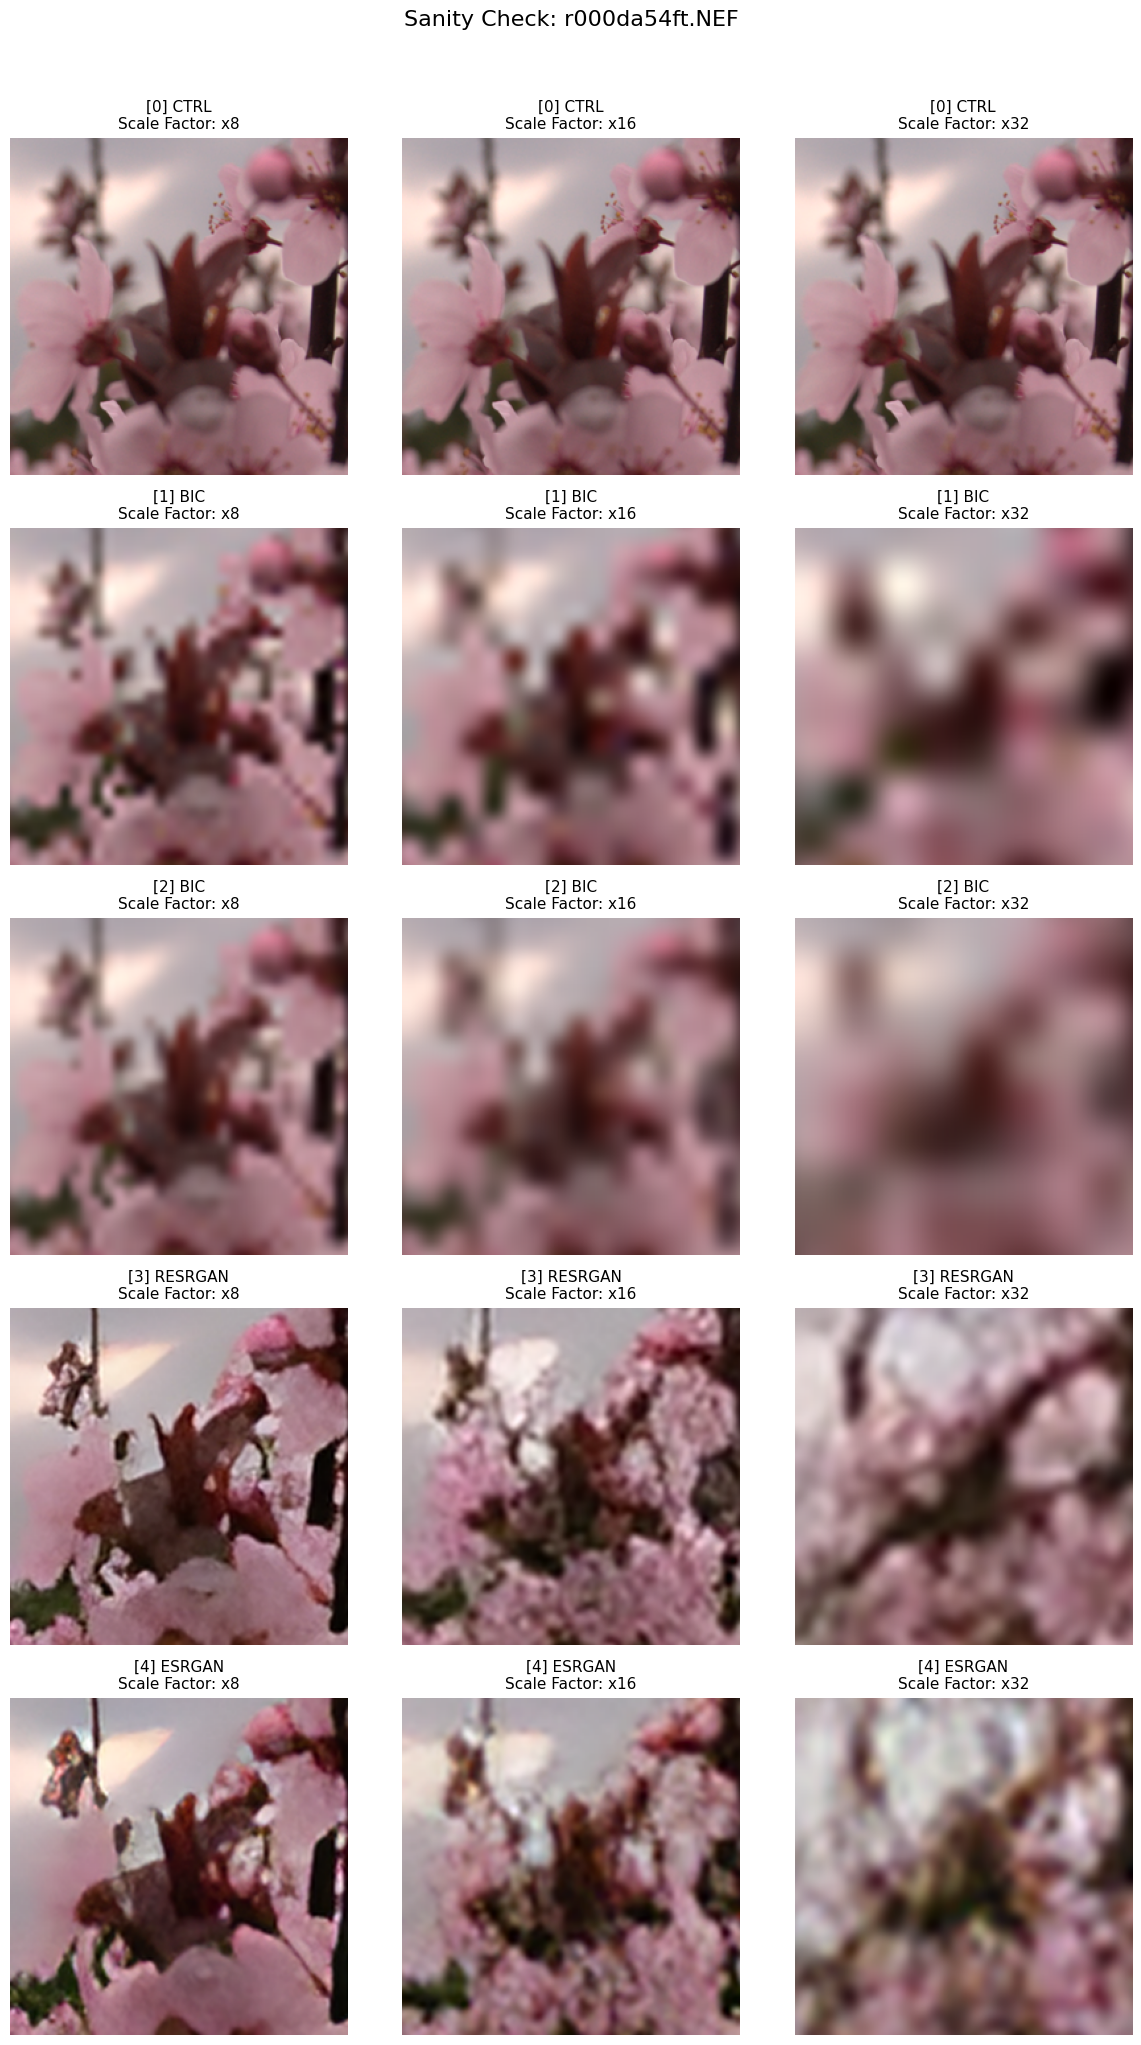

In [13]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

def run_sanity_check_grid():
    # 1. Pobranie pierwszego zdjęcia z folderu testowego
    image_files = sorted([f for f in os.listdir(INPUT_DIR) if f.lower().endswith(extensions)])
    if not image_files:
        print("🚨 Brak obrazów w INPUT_DIR!")
        return
        
    test_img_path = os.path.join(INPUT_DIR, image_files[1])
    print(f"📷 Sanity Check na obrazie: {image_files[0]}")
    
    # 2. Wczytanie i zabezpieczenie rozmiaru
    raw_pil = load_base_image(test_img_path)
    raw_pil.thumbnail((2048, 2048), Image.LANCZOS)
    
    # 3. Znalezienie JEDNEGO ciekawego punktu dla całej siatki
    rng = random.Random()
    crop_info = smart_crop(
        raw_pil, 
        raw_size=TARGET_CROP_SIZE, target_size=TARGET_CROP_SIZE,
        n_candidates=N_CANDIDATES, ent_min=ENTROPY_MIN, noise_var_max=NOISE_VAR_MAX, rng=rng
    )
    x, y = crop_info['top_left_xy']
    print(f"📍 Zamrożone współrzędne do porównania: x={x}, y={y}")

    # 4. Przygotowanie siatki Matplotlib
    n_rows = len(ALGORITHM_PAIRS)
    n_cols = len(SCALE_FACTORS)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    fig.suptitle(f"Sanity Check: {image_files[0]}", fontsize=16, y=1.02)
    
    # Normalizacja wymiarów `axes` do 2D (wiersze, kolumny)
    if n_rows == 1 and n_cols == 1: axes = [[axes]]
    elif n_rows == 1: axes = [axes]
    elif n_cols == 1: axes = [[ax] for ax in axes]

    # 5. Generowanie wariantów
    for row_idx, pair in enumerate(ALGORITHM_PAIRS):
        for col_idx, sf in enumerate(SCALE_FACTORS):
            
            # Skalowanie w dół i w górę
            low_res = pair['downscale'](raw_pil, sf)
            high_res = pair['upscale'](low_res, sf)
            
            # Wycięcie zamrożonego obszaru
            patch = high_res.crop((x, y, x + TARGET_CROP_SIZE, y + TARGET_CROP_SIZE))
            
            # Wyświetlanie na siatce
            ax = axes[row_idx][col_idx]
            ax.imshow(patch)
            
            title = f"[{pair['pair_id']}] {pair['up_abbr']}\nScale Factor: x{sf}"
            ax.set_title(title, fontsize=11)
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# Uruchomienie testu
run_sanity_check_grid()

### 4. KROK 9 — Pakowanie i Ewakuacja na Dysk Google
Gdy pipeline skończy pracę w `/content/1K_out`, użyj tego, aby bezpiecznie przenieść wszystko na swój Drive jako jeden plik ZIP.

In [11]:
import shutil
import os

# Konfiguracja
SOURCE_DIR = '/content/1K_out'
ZIP_NAME = SOURCE_DIR
DRIVE_DESTINATION = os.path.join(path, '1K_out')

if os.path.exists(SOURCE_DIR):
    print("📦 Pakowanie folderu do ZIP (to może chwilę potrwać)...")
    shutil.make_archive(ZIP_NAME, 'zip', SOURCE_DIR)
    
    print("🚀 Wysyłanie na Dysk Google...")
    shutil.copy(ZIP_NAME + '.zip', DRIVE_DESTINATION)
    
    print(f"✅ GOTOWE! Plik został zapisany na Twoim Dysku Google jako: {os.path.basename(DRIVE_DESTINATION)}")
else:
    print(f"❌ Nie znaleziono folderu źródłowego: {SOURCE_DIR}")

📦 Pakowanie folderu do ZIP (to może chwilę potrwać)...
🚀 Wysyłanie na Dysk Google...
✅ GOTOWE! Plik został zapisany na Twoim Dysku Google jako: 1K_out
